In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
# Download stock data

stocks = yf.download(
    ['AAPL', 'TSLA', 'NVDA', 'MSFT'],
    start='2023-01-01',
    end='2025-01-01'
)['Close']

stocks.head()

/tmp/ipykernel_4483/1972722697.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stocks = yf.download(
[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,MSFT,NVDA,TSLA
Date,,,,
2023-01-03,122.982719,233.452774,14.299910,108.099998
2023-01-04,124.251198,223.240829,14.733452,113.639999
2023-01-05,122.933563,216.624466,14.249963,110.339996
2023-01-06,127.456779,219.177444,14.843337,113.059998
2023-01-09,127.977928,221.311447,15.611526,119.769997


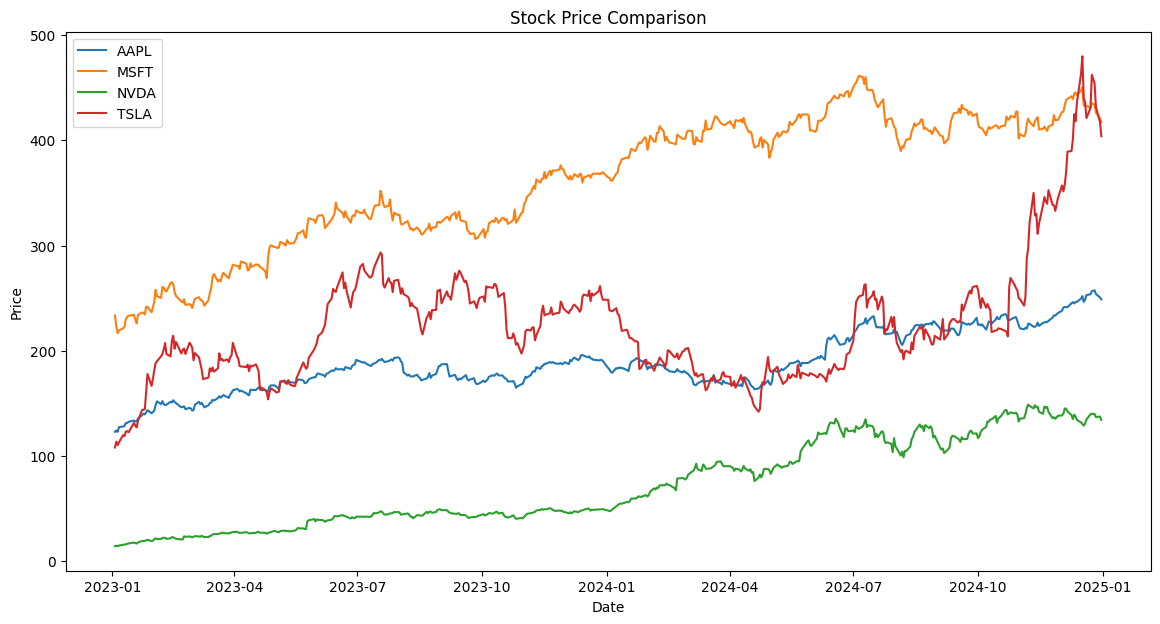

In [ ]:
plt.figure(figsize=(14,7))

for company in stocks.columns:
    plt.plot(stocks[company], label=company)

plt.title("Stock Price Comparison")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.show()

In [ ]:
returns = stocks.pct_change()

returns.head()

Ticker,AAPL,MSFT,NVDA,TSLA
Date,,,,
2023-01-03,NaN,NaN,NaN,NaN
2023-01-04,0.010314,-0.043743,0.030318,0.051249
2023-01-05,-0.010605,-0.029638,-0.032816,-0.029039
2023-01-06,0.036794,0.011785,0.041640,0.024651
2023-01-09,0.004089,0.009736,0.051753,0.059349


In [ ]:
# Average daily returns

mean_returns = returns.mean()

print(mean_returns)

Ticker
AAPL    0.001498
MSFT    0.001263
NVDA    0.004971
TSLA    0.003297
dtype: float64


This estimates:

average daily performance of each stock.

In [ ]:
cov_matrix = returns.cov()

print(cov_matrix)

Ticker      AAPL      MSFT      NVDA      TSLA
Ticker                                        
AAPL    0.000181  0.000097  0.000147  0.000186
MSFT    0.000097  0.000204  0.000225  0.000159
NVDA    0.000147  0.000225  0.001012  0.000349
TSLA    0.000186  0.000159  0.000349  0.001349


Covariance measures:

how stocks move together.

This is CENTRAL to portfolio optimization.

In [ ]:
weights = np.random.random(len(stocks.columns))

weights = weights / np.sum(weights)

print(weights)

[0.20810385 0.23253308 0.2756775  0.28368557]


In [ ]:
portfolio_return = np.sum(mean_returns * weights) * 252

print("Expected Annual Return:", portfolio_return)

Expected Annual Return: 0.7336135662785996


252 ≈ trading days in a year.

In [ ]:
portfolio_std = np.sqrt(
    np.dot(weights.T,
           np.dot(cov_matrix * 252, weights))
)

print("Portfolio Risk:", portfolio_std)

Portfolio Risk: 0.29989866546130134


In [ ]:
# Simulating portfolios

num_portfolios = 5000

portfolio_returns = []

portfolio_risks = []

for i in range(num_portfolios):

    weights = np.random.random(len(stocks.columns))

    weights /= np.sum(weights)

    returns_portfolio = np.sum(mean_returns * weights) * 252

    risk_portfolio = np.sqrt(
        np.dot(weights.T,
               np.dot(cov_matrix * 252, weights))
    )

    portfolio_returns.append(returns_portfolio)

    portfolio_risks.append(risk_portfolio)

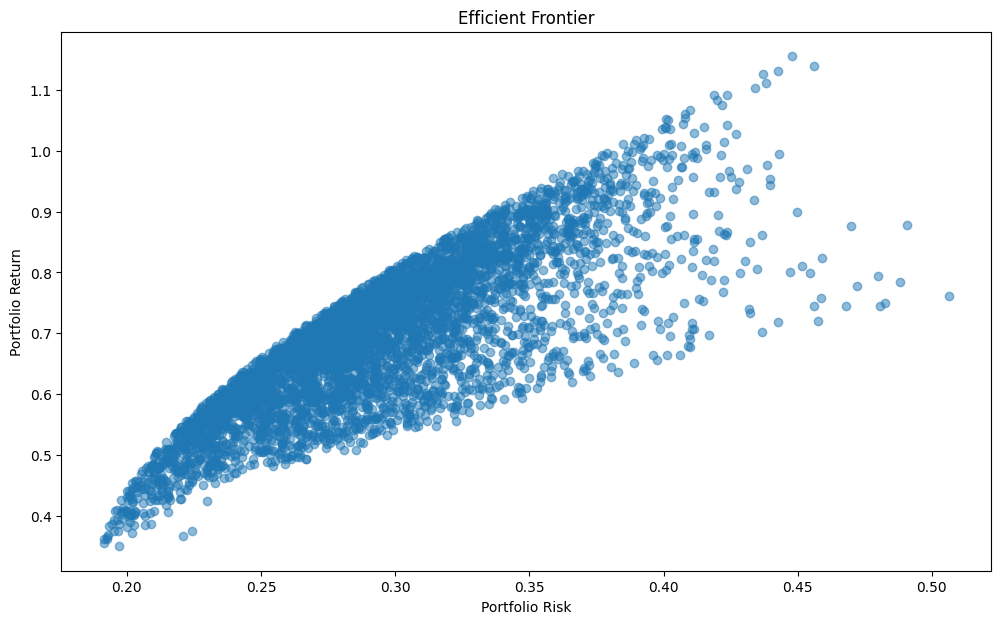

In [ ]:
plt.figure(figsize=(12,7))

plt.scatter(portfolio_risks,
            portfolio_returns,
            alpha=0.5)

plt.title("Efficient Frontier")

plt.xlabel("Portfolio Risk")

plt.ylabel("Portfolio Return")

plt.show()

The chart above is*** Efficient Frontier***
It shows: Best possible return for different risk levels.

# Portfolio Optimization Using Python

## Importing Libraries

## Downloading Stock Data

## Return Analysis

## Covariance Matrix

## Portfolio Return Calculation

## Portfolio Risk Calculation

## Efficient Frontier Visualization